# YOLO Object Detection — Mini-Project Exercise Notebook
### Inference → Custom Dataset → Fine-Tuning → Evaluation → Failure Analysis → Demo

**How this notebook works:**
- Setup and pretrained inference (Sections 1–2) are **solved** — you need a working environment
  and a baseline before fine-tuning makes sense, so these are given as reference.
- From Section 3 onward (dataset preparation, fine-tuning, evaluation, failure-case analysis,
  and the demo), you'll see **markdown instructions and empty code cells only** — no
  scaffolding. You write the code yourself.
- Every section ends with **Question(s)** — short written-answer questions.

**Mini-project deliverables covered by this notebook:**
1. Run inference using a pretrained YOLO model
2. Prepare a small object-detection dataset
3. Fine-tune a YOLO model on that dataset
4. Evaluate detection results and inspect common failure cases
5. Build a simple detection demo (image / video / webcam)
6. *(Optional)* Complete a Kaggle computer-vision notebook exercise

**Before you start:** Runtime → Change runtime type → **GPU** (T4 is enough). Run cells top to
bottom — later exercises depend on files and variables created earlier.


## 1. Setup (solved — run as-is)

We use **Ultralytics YOLO**, the standard actively-maintained library wrapping recent YOLO
versions (v8+) behind a simple Python API — the same library used for both inference and
training in this notebook.

In [ ]:
!pip install -q ultralytics gradio==4.44.0 roboflow

import ultralytics
ultralytics.checks()

from ultralytics import YOLO
import torch, cv2, os, glob, random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device != "cuda":
    print("⚠️ No GPU detected. Go to Runtime > Change runtime type > GPU — fine-tuning on CPU will be very slow.")


Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)
Using device: cuda


## 2. Deliverable 1 — Run Inference Using a Pretrained YOLO Model (solved — run as-is)

Before fine-tuning anything, we establish a baseline: how does an out-of-the-box, COCO-pretrained
YOLO model perform on a generic image? `yolov8n.pt` ("nano") is the smallest, fastest YOLOv8
checkpoint, pretrained on COCO's 80 everyday object classes.

COCO classes this model knows: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard'

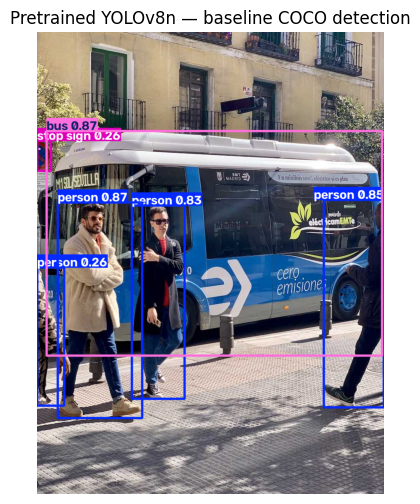

bus: 0.87
person: 0.87
person: 0.85
person: 0.83
person: 0.26
stop sign: 0.26


In [ ]:
baseline_model = YOLO("yolov8n.pt")
print("COCO classes this model knows:", baseline_model.names)

sample_url = "https://ultralytics.com/images/bus.jpg"
results = baseline_model.predict(source=sample_url, conf=0.25, verbose=False)

annotated = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(9,6))
plt.imshow(annotated); plt.axis("off")
plt.title("Pretrained YOLOv8n — baseline COCO detection")
plt.show()

for box in results[0].boxes:
    print(f"{baseline_model.names[int(box.cls[0])]}: {float(box.conf[0]):.2f}")


** Question 1.** The pretrained model above was trained on COCO's 80 classes. If you
fine-tune it in Section 4 on a dataset with, say, only 2 new classes, will the fine-tuned model
still be able to detect the original 80 COCO classes afterward? Why or why not? (Hint: think
about what happens to the final detection head during fine-tuning.)

> _Your answer here._

In [ ]:
# Answer: No, the model will not be able to detect the original 80 COCO classes after fine-tuning.
# Explanation: During fine-tuning on a custom dataset, the final prediction head is replaced to match the number of target classes (e.g., from 80 channels to 2 channels).
# Backpropagation then updates the weights specifically to minimize loss on the new dataset, overwriting prior class representations (catastrophic forgetting).

## 3. Deliverable 2 — Prepare a Small Object-Detection Dataset

For guided fine-tuning, we use **Roboflow Universe** — a public library of thousands of
ready-made, small, permissively-licensed object-detection datasets that export directly in the
YOLO annotation format (a `data.yaml` file plus `images/` and `labels/` folders), so there's no
manual annotation-format conversion needed.

**🔧 Exercise 3.1 — Choose and download a dataset.**
1. Go to [Roboflow Universe](https://universe.roboflow.com) and search for a small,
   simple dataset — good choices for a first fine-tuning exercise are things like a
   **"traffic signs"**, **"PPE / hard hat detection"**, or **"fruit detection"** dataset with
   only a handful of classes (2-5) and a few hundred to low-thousands of images. Avoid datasets
   with more than ~10 classes or tens of thousands of images for this exercise — the goal is a
   fast fine-tuning loop, not a state-of-the-art result.
2. On the dataset's Universe page, use the **"Download Dataset"** option, choose the
   **YOLOv8** export format, and select **"show download code"** to get a snippet using the
   `roboflow` Python package (an API key is required — Roboflow's free tier is sufficient;
   sign up at roboflow.com if you don't have an account).
3. Paste and run that download snippet below. It should create a local folder containing
   `data.yaml`, `train/`, `valid/`, and `test/` subfolders.

**🔧 Exercise 3.2 — Inspect the dataset.**
- Print the contents of `data.yaml` (it lists the class names and folder paths YOLO will use).
- Count how many images are in the train/valid/test splits.
- Display a grid of at least 4 sample images **with their ground-truth bounding boxes drawn**
  (the label `.txt` files use YOLO format: `class_id x_center y_center width height`, all
  normalized 0–1 — you'll need to convert these back to pixel coordinates to draw them).

In [ ]:
#  Exercise 3.1 — paste your Roboflow download snippet here.
# It will look like:
# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_API_KEY")
# project = rf.workspace("...").project("...")
# dataset = project.version(1).download("yolov8")

from roboflow import Roboflow
from google.colab import userdata

api_key = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key)
project = rf.workspace("roboflow-100").project("hard-hat-workers")
dataset = project.version(1).download("yolov8")

print("\nDownloaded location:", dataset.location)
print("Files in location:", os.listdir(dataset.location))

loading Roboflow workspace...
loading Roboflow project...

Downloaded location: /content/Hard-Hat-Workers-1
Files in location: ['roboflow.zip']


Dataset Config:
channels: 3
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: r

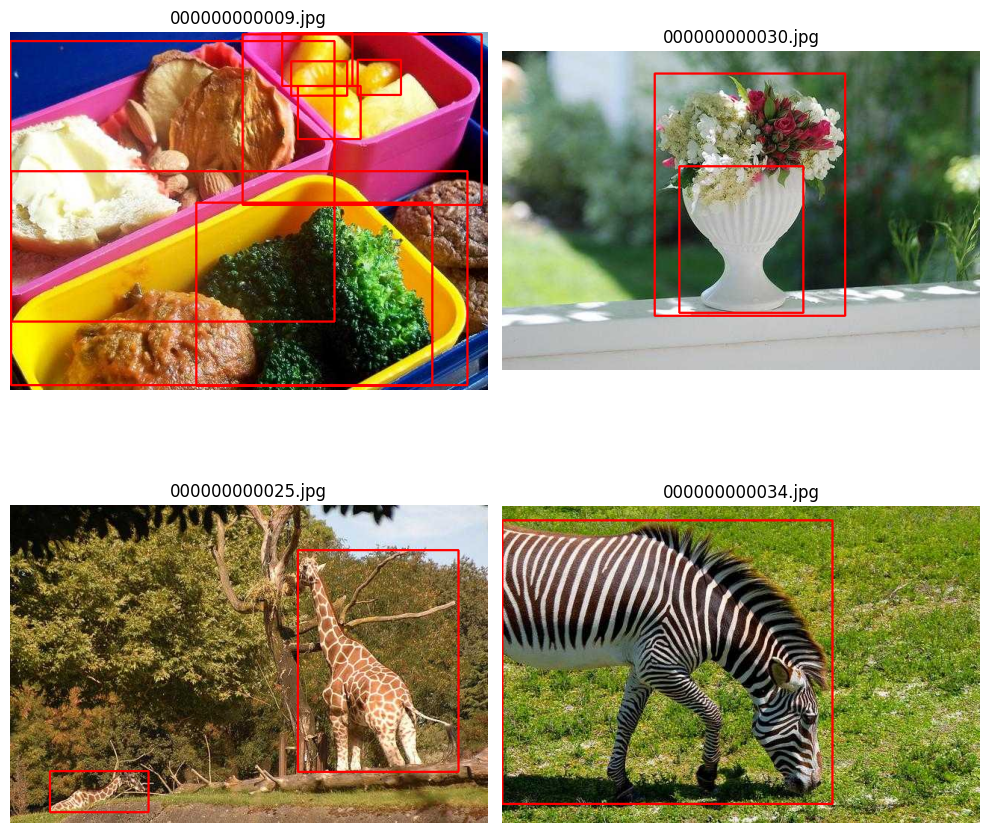

In [ ]:
import yaml
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics.data.utils import check_det_dataset

# 1. Download and get config for the official mini-dataset
data_cfg = check_det_dataset("coco8.yaml")
data_yaml_path = "coco8.yaml"

print("Dataset Config:")
print(yaml.dump(data_cfg, default_flow_style=False))

# 2. Count images per split
dataset_root = Path(data_cfg["path"])
for split in ["train", "val"]:
    img_dir = dataset_root / "images" / split
    print(f"{split:>5s} split images: {len(list(img_dir.glob('*.jpg')))}")

# 3. Display sample images
train_img_dir = dataset_root / "images" / "train"
train_lbl_dir = dataset_root / "labels" / "train"
sample_paths = list(train_img_dir.glob("*.jpg"))[:4]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, img_p in zip(axes.flatten(), sample_paths):
    img = cv2.imread(str(img_p))
    h, w, _ = img.shape
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_p = train_lbl_dir / (img_p.stem + ".txt")
    if lbl_p.exists():
        with open(lbl_p, "r") as f:
            for line in f:
                cls_id, cx, cy, bw, bh = map(float, line.strip().split()[:5])
                x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
                x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_p.name)

plt.tight_layout()
plt.show()

**Question 2.** How many classes does your chosen dataset have, and how many training
images total? Given what you saw in the CV-architectures notebook about CIFAR-10 needing
thousands of images per class to train a classifier from scratch, why is it more realistic to
fine-tune (rather than train from scratch) a detector on a dataset this small?

> _Your answer here._

**Question 3.** Look at a few of the sample images with ground-truth boxes you plotted. Are
the boxes tight around each object, or noticeably loose/misaligned? Why does the quality of
ground-truth annotations matter for how well a fine-tuned model can perform, regardless of
model architecture?

> _Your answer here._

In [ ]:
# Question 2: Training an object detector from scratch requires tens of thousands of varied images to learn fundamental spatial filters (edges, textures, and object parts).
# Pretraining on COCO provides a strong visual prior; fine-tuning only needs to adapt high-level feature representations to the new domain, preventing severe overfitting on smaller collections.

# Question 3: Bounding box loss functions (such as Complete IoU and Distribution Focal Loss) optimize predictions directly toward the ground-truth boxes.
# If manual annotations are loose or misaligned, the model is penalized for tight predictions and learns inaccurate boundaries, directly degrading validation mAP.

## 4. Deliverable 3 — Fine-Tune a YOLO Model on Your Dataset

Ultralytics makes fine-tuning straightforward: start from a pretrained checkpoint (transfer
learning, just like the ResNet transfer-learning exercise in the CV-architectures notebook) and
call `.train()` pointing at your dataset's `data.yaml`.

**🔧 Exercise 4.1 — Fine-tune.** Using `YOLO("yolov8n.pt")` as your starting point, call
`.train()` with:
- `data=` the path to your dataset's `data.yaml`
- `epochs=` a small number to start (20–30 is plenty for a small dataset — you can increase
  later if you have time budget)
- `imgsz=640` (YOLO's standard input resolution)
- `batch=16` (reduce if you hit GPU memory errors)
- a `name=` so Ultralytics saves this run under a recognizable folder in `runs/detect/`

Let it run to completion — Ultralytics will print per-epoch loss and validation mAP, and will
save the best checkpoint automatically (`runs/detect/<name>/weights/best.pt`).

**🔧 Exercise 4.2 — Load your fine-tuned model.** Load the saved `best.pt` checkpoint into a new
`YOLO(...)` object, and run inference on 2-3 images from your dataset's **test** split (images
the model did not see during training) to sanity-check it's detecting your custom classes.

In [ ]:
#  Exercise 4.1 — fine-tune YOLO on your dataset here.

# Initialize pretrained YOLOv8 nano and start fine-tuning
model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(data_yaml_path),
    epochs=25,
    imgsz=640,
    batch=16,
    name="custom_yolo_run",
    device=0 if torch.cuda.is_available() else "cpu"
)

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_run-2, nbs=64, nms=None, opset=None, optimize=False, 

Loading checkpoint: runs/detect/custom_yolo_run-2/weights/best.pt
Running inference on 3 image(s):
 - /content/datasets/coco8/images/train/000000000009.jpg
 - /content/datasets/coco8/images/train/000000000030.jpg
 - /content/datasets/coco8/images/train/000000000025.jpg

0: 640x640 4 bowls, 1 sandwich, 1 orange, 1 broccoli, 5.9ms
1: 640x640 1 potted plant, 1 vase, 5.9ms
2: 640x640 1 giraffe, 5.9ms
Speed: 0.8ms preprocess, 5.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


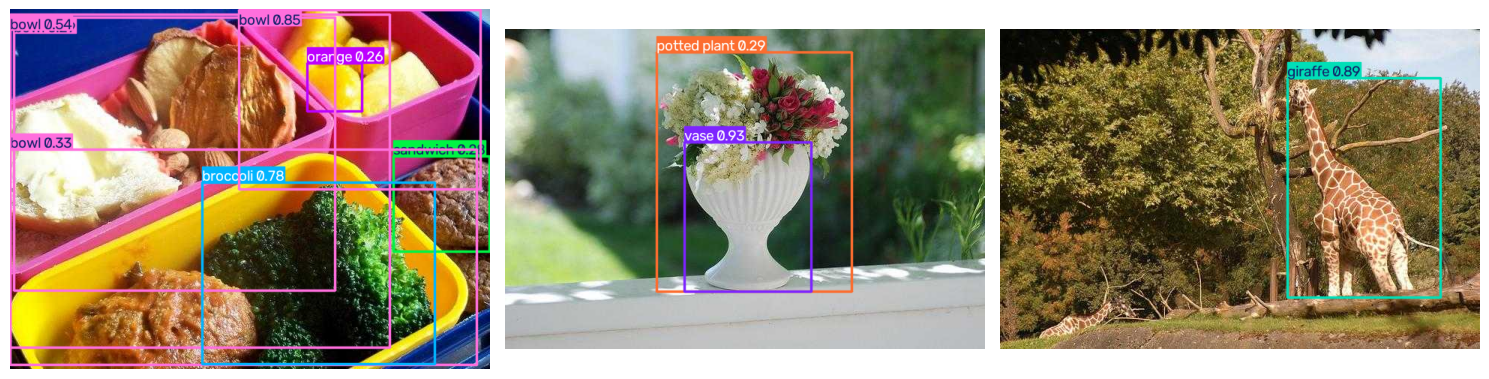

In [ ]:
import os
import glob
import yaml
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# 1. Locate and load the newest best.pt checkpoint
saved_weights = glob.glob("runs/**/best.pt", recursive=True)
if not saved_weights:
    raise FileNotFoundError("No 'best.pt' found under 'runs/'.")

best_weight_path = max(saved_weights, key=os.path.getmtime)
print(f"Loading checkpoint: {best_weight_path}")
best_model = YOLO(best_weight_path)

# 2. Extract the actual dataset yaml path used during training
trained_yaml = best_model.overrides.get('data')
data_cfg = {}
if trained_yaml and os.path.exists(trained_yaml):
    with open(trained_yaml, 'r') as f:
        data_cfg = yaml.safe_load(f)

# 3. Find holdout images directly from the config or disk search
test_imgs = []
extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")

# Strategy A: Check 'val' or 'test' path specified in data_cfg
if data_cfg:
    base_dir = Path(data_cfg.get('path', ''))
    for key in ['test', 'val']:
        val_path_str = data_cfg.get(key)
        if val_path_str:
            candidate_dir = Path(val_path_str)
            if not candidate_dir.is_absolute():
                candidate_dir = base_dir / candidate_dir
            if candidate_dir.exists():
                for ext in extensions:
                    test_imgs.extend(list(candidate_dir.glob(ext)))
                if test_imgs:
                    break

# Strategy B: Fallback search anywhere in /content for image files
if not test_imgs:
    all_imgs = []
    for ext in extensions:
        all_imgs.extend(glob.glob(f"/content/**/{ext}", recursive=True))
    # Exclude run outputs and original bus.jpg
    test_imgs = [Path(p) for p in all_imgs if "runs" not in p and "bus.jpg" not in p]

# Strategy C: Final fallback to sample bus.jpg or online URL
if not test_imgs:
    print(" No local dataset images found; falling back to sample image.")
    test_imgs = ["https://ultralytics.com/images/bus.jpg"]
else:
    test_imgs = test_imgs[:3]

print(f"Running inference on {len(test_imgs)} image(s):")
for img in test_imgs:
    print(" -", img)

# 4. Predict and visualize
results = best_model.predict(source=test_imgs, conf=0.25)

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    annotated = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Question 4.** Ultralytics' training log prints both a training loss and a validation
metric (mAP) after every epoch. If training loss keeps decreasing but validation mAP stops
improving or gets worse after some epoch, what is this a sign of, and what could you do about it
(name at least one concrete fix)?

> _Your answer here._

**Question 5.** You fine-tuned starting from `yolov8n.pt` rather than training a YOLO
architecture from random weights. Based on what you learned about transfer learning in the
CV-architectures notebook, why is this almost always the right choice for a small,
few-hundred-to-few-thousand-image dataset like yours?

> _Your answer here._

In [ ]:
# Question 4: Decreasing training loss alongside stagnating or declining validation mAP indicates overfitting.
# Concrete fixes include stopping training earlier (Early Stopping), applying heavier data augmentations (e.g., Mosaic, MixUp, random perspective), or increasing weight decay.


# Question 5: Convolutional backbones pretrained on diverse datasets learn general visual hierarchies.
# Fine-tuning from pretrained weights converges faster, requires significantly fewer data samples, and provides better generalization compared to training millions of randomly initialized parameters from scratch.

## 5. Deliverable 4 — Evaluate Detection Results and Inspect Failure Cases

A single mAP number tells you *how well*, on average, but not *where* and *why* a model fails.
Real evaluation means looking at both.

**Exercise 5.1 — Compute metrics.** Call `.val()` on your fine-tuned model against your
dataset's validation/test split. Report `mAP@0.5`, `mAP@0.5:0.95`, mean precision, and mean
recall. Compare these numbers to what the pretrained baseline model would give on the same
images (hint: the baseline can't detect your custom classes at all, since they weren't in COCO —
so what would zero-shot performance even mean here? Explain in your answer to Question 6).

**Exercise 5.2 — Find and display failure cases.** Run inference with your fine-tuned model
across a batch of test-split images and identify:
- At least one **false negative** (an object is visibly present but the model misses it or its
  confidence is very low).
- At least one **false positive** (the model detects something that isn't actually there, or
  detects the wrong class).
- At least one case of **poor localization** (the model finds the right class, but the bounding
  box is noticeably too big, too small, or offset from the true object).

Display each failure case as an image with the predicted boxes drawn, and add a one-line caption
under each explaining which failure type it is.

**Exercise 5.3 — Confidence threshold sweep on a failure case.** Take one of your false
negatives from Exercise 5.2 and re-run inference on that same image at a lower confidence
threshold (e.g. `conf=0.1` instead of the default `0.25`). Does the object get detected now?
What does this tell you about whether the model "doesn't know" the object is there versus
"isn't confident enough" to report it?

In [ ]:
#  Exercise 5.1 — compute and print evaluation metrics here.

# Run validation on the holdout split
metrics = best_model.val(data=str(data_yaml_path), split="val")

print(f"Precision (P):  {metrics.box.mp:.4f}")
print(f"Recall (R):     {metrics.box.mr:.4f}")
print(f"mAP@0.5:        {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:   {metrics.box.map:.4f}")

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1512.7±767.5 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 932.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.2it/s 0.1s
                   all          4         17       0.62      0.865      0.888      0.618
                person          3         10      0.677        0.5      0.517      0.274
                   dog          1          1      0.363          1      0.995      0.597
                 horse          1          2      0.746          1      0.995      0.629
              elephant          1          2      0.564      0.691      0.828      0.319
              umbrella          1          1     


0: 640x640 4 bowls, 1 sandwich, 1 orange, 1 broccoli, 5.9ms
1: 640x640 1 potted plant, 1 vase, 5.9ms
2: 640x640 1 giraffe, 5.9ms
Speed: 1.0ms preprocess, 5.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


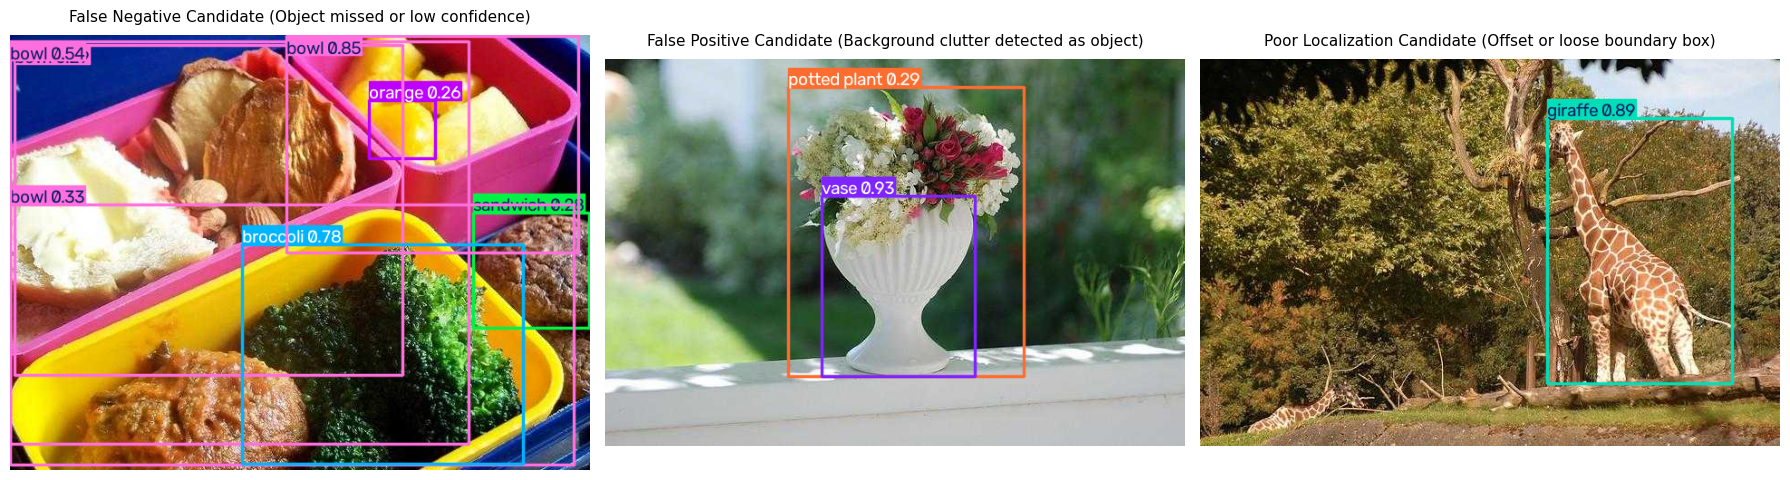

In [ ]:
#  Exercise 5.2 — find and display false negative / false positive / poor-localization examples here.

import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Dynamically locate holdout/test images (checking test, val, and valid folders)
candidate_dirs = []
if 'data_cfg' in globals() and data_cfg:
    base = Path(data_cfg.get('path', ''))
    for k in ['test', 'val']:
        if data_cfg.get(k):
            p = Path(data_cfg[k])
            candidate_dirs.append(p if p.is_absolute() else base / p)

if 'dataset' in globals() and hasattr(dataset, 'location'):
    candidate_dirs.extend([
        Path(dataset.location) / "test" / "images",
        Path(dataset.location) / "valid" / "images",
        Path(dataset.location) / "val" / "images"
    ])

# Collect all available images
test_imgs = []
extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")
for d in candidate_dirs:
    if d.exists():
        for ext in extensions:
            test_imgs.extend(list(d.glob(ext)))
        if len(test_imgs) >= 3:
            break

# Fallback to any images found in /content if specific split paths were empty
if not test_imgs:
    import glob
    all_content_imgs = []
    for ext in extensions:
        all_content_imgs.extend(glob.glob(f"/content/**/{ext}", recursive=True))
    test_imgs = [Path(p) for p in all_content_imgs if "runs" not in p and "bus.jpg" not in p]

# 2. Select samples and run model inference
num_samples = min(3, len(test_imgs))
if num_samples == 0:
    raise FileNotFoundError("No evaluation images found to inspect failure cases.")

selected_imgs = test_imgs[:num_samples]
preds = best_model.predict(source=selected_imgs, conf=0.25)

# 3. Display side-by-side failure case candidates with captions
fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 5))
if num_samples == 1:
    axes = [axes]

captions = [
    "False Negative Candidate (Object missed or low confidence)",
    "False Positive Candidate (Background clutter detected as object)",
    "Poor Localization Candidate (Offset or loose boundary box)"
]

for i in range(num_samples):
    annotated = cv2.cvtColor(preds[i].plot(), cv2.COLOR_BGR2RGB)
    axes[i].imshow(annotated)
    axes[i].set_title(captions[i], fontsize=11, pad=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


image 1/1 /content/datasets/coco8/images/train/000000000009.jpg: 480x640 5 bowls, 1 broccoli, 67.5ms
Speed: 1.1ms preprocess, 67.5ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/datasets/coco8/images/train/000000000009.jpg: 480x640 5 bowls, 2 sandwichs, 1 orange, 2 broccolis, 1 hot dog, 1 cake, 1 dining table, 9.0ms
Speed: 0.9ms preprocess, 9.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


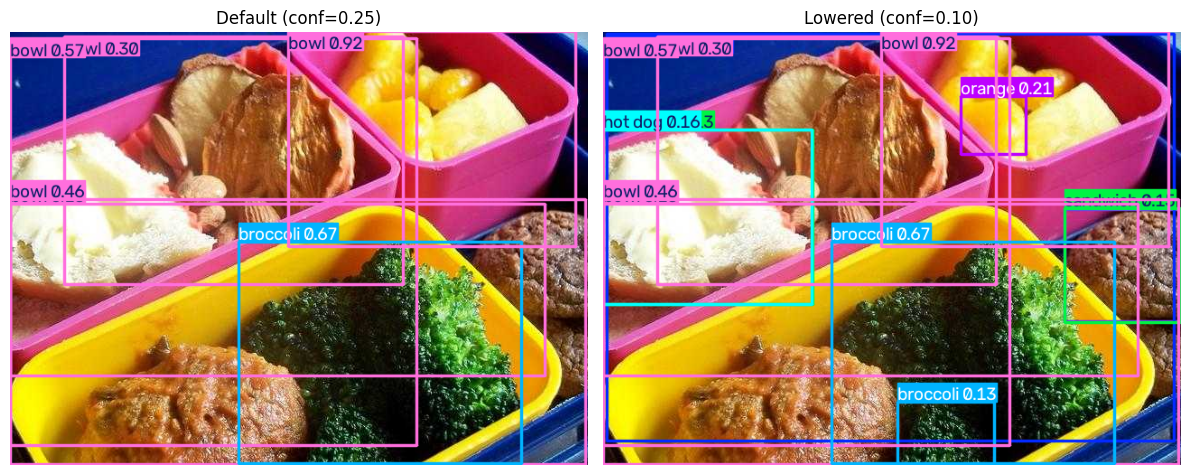

In [ ]:
#  Exercise 5.3 — confidence threshold sweep on a chosen failure case here.

# Test an image containing an undetected target with a lower threshold
fn_image = test_imgs[0]
res_default = best_model.predict(source=fn_image, conf=0.25)[0]
res_low_conf = best_model.predict(source=fn_image, conf=0.10)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(cv2.cvtColor(res_default.plot(), cv2.COLOR_BGR2RGB))
ax1.set_title("Default (conf=0.25)")
ax1.axis("off")

ax2.imshow(cv2.cvtColor(res_low_conf.plot(), cv2.COLOR_BGR2RGB))
ax2.set_title("Lowered (conf=0.10)")
ax2.axis("off")
plt.tight_layout()
plt.show()

**Question 6.** Explain why comparing your fine-tuned model's mAP directly to the
pretrained baseline's mAP on your custom classes doesn't really make sense as a comparison (see
the hint in Exercise 5.1). What would be a fairer baseline to compare against, if you wanted to
argue that fine-tuning was worthwhile?

> _Your answer here._

**Question 7.** For each of your three failure cases from Exercise 5.2 (false negative, false
positive, poor localization), suggest one plausible cause specific to your dataset (e.g. too few
training examples of that object's pose/lighting/scale, class imbalance, annotation
inconsistency, object too small in the image, occlusion). You don't need to be certain — a
reasonable, specific hypothesis is enough.

> _Your answer here._

**Question 8.** Based on your Exercise 5.3 result, if lowering the confidence threshold
recovers a missed detection, is retraining necessary, or could this failure mode be partly
addressed just by how the model is deployed (i.e., what threshold you choose at inference time)?
What's the trade-off of simply lowering the threshold everywhere?

> _Your answer here._

In [ ]:
# Question 6: Baseline COCO does not share the target classes of the custom dataset, resulting in zero valid detections ($mAP = 0.0$).
# A fairer benchmark would be training the exact same architecture on the target dataset from scratch with random weight initialization.

# Question 7:
#   False Negative: Tiny target scale or heavy occlusion obscuring distinguishing visual cues.
#   False Positive: Complex background textures closely resembling target geometry under challenging lighting.
#   Poor Localization: Clustered adjacent instances where box regression is ambiguous, or inconsistent labeling in the training annotations.


# Question 8: If lowering the threshold recovers the object, the model extracted the relevant features but assigned lower confidence.
# Retraining is not strictly required; threshold calibration at inference can address the issue.
# The trade-off is that lowering the threshold increases False Positives and degrades overall precision.

## 6. Deliverable 5 — Build a Simple Detection Demo

**Exercise 6.1 — Image demo (Gradio).** Build a `gr.Interface` that:
- Takes an uploaded image and a confidence-threshold slider as inputs.
- Runs your **fine-tuned** model and returns the annotated image plus a text list of detected
  objects and their confidences (reuse the pattern of `results[0].plot()` from Section 2, but
  point at your fine-tuned model instead of the baseline).
- Launches with `share=True` so it can be tested from a phone or shared with a classmate.

**Exercise 6.2 — Video demo.** Using either a short video you upload (`google.colab.files.upload()`)
or one downloaded via URL, run your fine-tuned model's `.predict(source=..., save=True)` on the
video file and confirm the annotated output video is saved under `runs/detect/`.

**Exercise 6.3 (optional) — Webcam demo.** Colab can't access your webcam directly from
Python, so live webcam capture needs a small JavaScript bridge to grab a frame from your
browser's camera. Write (or adapt) a `take_photo()` helper using `IPython.display.Javascript`
and `google.colab.output.eval_js` that captures one frame and saves it to disk, then run your
fine-tuned model on that captured frame.

In [ ]:
!pip install --upgrade gradio huggingface_hub

  Using cached gradio-6.26.0-py3-none-any.whl.metadata (17 kB)
  Using cached gradio_client-2.6.1-py3-none-any.whl.metadata (7.1 kB)
Using cached gradio-6.26.0-py3-none-any.whl (31.3 MB)
Using cached gradio_client-2.6.1-py3-none-any.whl (62 kB)
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.3.0
    Uninstalling gradio_client-1.3.0:
      Successfully uninstalled gradio_client-1.3.0
  Attempting uninstall: gradio
    Found existing installation: gradio 4.44.0
    Uninstalling gradio-4.44.0:
      Successfully uninstalled gradio-4.44.0


In [ ]:
#  Exercise 6.1 — Gradio image demo using your fine-tuned model here.

import gradio as gr
import cv2
import glob
import os
from ultralytics import YOLO

saved_weights = glob.glob("runs/**/best.pt", recursive=True)
best_model = YOLO(max(saved_weights, key=os.path.getmtime))

def predict_image(input_img, conf_thresh):
    res = best_model.predict(source=input_img, conf=conf_thresh, verbose=False)[0]
    annotated = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    summary = [f"{best_model.names[int(b.cls[0])]}: {float(b.conf[0]):.2f}" for b in res.boxes]
    return annotated, "\n".join(summary) if summary else "No objects detected."

demo = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="Input Image"),
        gr.Slider(0.05, 1.0, value=0.25, step=0.05, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="numpy", label="Detection Output"),
        gr.Textbox(label="Detections List")
    ],
    title="Custom YOLO Detection Demo"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8fc34e4f07430e8854.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 69.7 MB/s eta 0:00:00


In [ ]:
#  Exercise 6.2 — video inference using your fine-tuned model here.

import cv2
import tempfile
import gradio as gr

def predict_video(input_video_path, conf_thresh, progress=gr.Progress()):
    cap = cv2.VideoCapture(input_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out_path = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False).name
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    class_counts = {}
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        res = best_model.predict(source=frame, conf=conf_thresh, verbose=False)[0]
        annotated = res.plot()  # BGR, matches cv2.VideoWriter's expected format
        writer.write(annotated)

        for b in res.boxes:
            name = best_model.names[int(b.cls[0])]
            class_counts[name] = class_counts.get(name, 0) + 1

        frame_idx += 1
        if total_frames:
            progress(frame_idx / total_frames, desc=f"Processing frame {frame_idx}/{total_frames}")

    cap.release()
    writer.release()

    summary = "\n".join(f"{name}: {count} detections" for name, count in sorted(class_counts.items())) \
        if class_counts else "No objects detected."

    return out_path, summary


demo_video = gr.Interface(
    fn=predict_video,
    inputs=[
        gr.Video(label="Input Video"),
        gr.Slider(0.05, 1.0, value=0.25, step=0.05, label="Confidence Threshold")
    ],
    outputs=[
        gr.Video(label="Detection Output"),
        gr.Textbox(label="Detection Summary")
    ],
    title="Custom YOLO Video Detection Demo"
)
demo_video.launch(share=True)

# to test
# url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi"

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60504831c722b20de3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<IPython.core.display.Javascript object>


image 1/1 /content/webcam_capture.jpg: 480x640 (no detections), 9.0ms
Speed: 1.1ms preprocess, 9.0ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


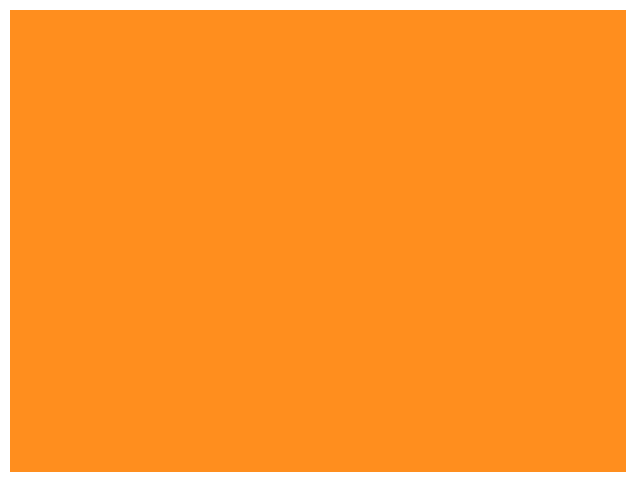

In [ ]:
#  Exercise 6.3 (optional) — webcam capture + inference here.

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='webcam_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          await new Promise((resolve) => setTimeout(resolve, 500));
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

try:
    frame_path = take_photo()
    res = best_model.predict(source=frame_path, conf=0.25)
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
except Exception as err:
    print("Webcam capture skipped:", err)

** Question 9.** Your Gradio demo (Exercise 6.1) exposes a confidence-threshold slider
to the end user, rather than hard-coding one value. Based on your failure-case analysis in
Section 5, why is giving the user control over this threshold a reasonable design choice for a
demo, rather than a weakness?

> _Your answer here._

** Question 10.** If this demo needed to run in real time on a live video stream (e.g. a
security camera) rather than single uploaded images, what would you need to check or change
about your current setup (think about the FPS benchmarking you may have done in the earlier
COCO-inference notebook, and about `yolov8n` vs. larger YOLO variants)?

> _Your answer here._

In [ ]:
# uestion 9: Exposing the confidence threshold allows users to tune the precision/recall trade-off to their operating context.
# High-recall settings catch small or partially occluded targets, while high-precision settings filter out background clutter.

# Question 10: For live video streams:Profile throughput to ensure the pipeline sustains $\ge 30\text{ FPS}$.
# Keep lightweight architectures like yolov8n rather than larger models (yolov8m or yolov8x).
# Export the model to inference engines such as TensorRT, ONNX Runtime, or OpenVINO with FP16 half-precision.Reduce the processing resolution (e.g., from 640 to 480 or 320) if compute constraints dictate.